# ANA500 Micro-Project 4 - Beijing PM2.5 Forecasting

Jesus Adrian Alvarado Gadea
ANA500, National University

The final micro-project applies deep learning regression techniques, including recurrent
neural networks, to time-series data, and runs the full data science process through
Step 5 (Act).

**Why the dataset changes here.** The Adult extract used in Micro-Projects 1 through 3 is
a single 1994 cross-section with no time dimension, which was flagged as a handoff item at
the end of Micro-Project 3. This project introduces an hourly time series so that
recurrent networks have an actual sequence to read.

**Problem statement:** Fine-particle air pollution (PM2.5) in Beijing swings sharply from
hour to hour, and dangerous episodes arrive with little warning. Exposure decisions such
as advisories, school activity, and sensitive-group warnings depend on the next few hours,
not the season. The phenomenon I want to describe is how the next hour's PM2.5
concentration relates to the recent history of pollution and weather.

**Hypothesis:** The recent 24 hours of pollution and weather carry predictive signal
beyond the current reading alone. Concretely: (a) models using that history will beat a
persistence forecast that just repeats the last observed value, and (b) recurrent networks
that read the window as an ordered sequence will outperform memoryless models that see the
same window as a flat list of numbers.

**Feedback applied from Micro-Project 3.** The graded deck marked the deliberate fitting
of regression methods to a binary target. The lesson carried here is to match the
technique to the target: this target is continuous, so regression networks apply directly,
and the linear regression that needed a workaround in Micro-Project 3 serves as a properly
posed baseline in this one.

In [1]:
import os
import time
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"   # silence TensorFlow's Python-side logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# TensorFlow's C++ startup notes bypass the setting above and write straight to
# the error stream, so the import happens with that stream parked on /dev/null
quiet, keep = os.open(os.devnull, os.O_WRONLY), os.dup(2)
os.dup2(quiet, 2)
import tensorflow as tf
from tensorflow import keras
os.dup2(keep, 2)
os.close(quiet)
os.close(keep)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 95)
Path("fig").mkdir(exist_ok=True)

# one seed for numpy, python, and tensorflow together
keras.utils.set_random_seed(500)

print("tensorflow", tf.__version__)

tensorflow 2.21.0


## Step 1 - Acquire

Dataset: Beijing PM2.5 Data Set, UCI Machine Learning Repository, dataset ID 381.

Citation: Liang, X., Zou, T., Guo, B., Li, S., Zhang, H., Zhang, S., Huang, H. and Chen,
S. X. (2015). Assessing Beijing's PM2.5 pollution: severity, weather impact, APEC and
winter heating. Proceedings of the Royal Society A, 471(2182). Dataset hosted by the UCI
Machine Learning Repository under a CC BY 4.0 license.

The file contains 43,824 hourly rows covering January 1, 2010 through December 31, 2014:
PM2.5 concentration measured at the US Embassy in Beijing, paired with meteorology from
Beijing Capital International Airport (dew point, temperature, pressure, combined wind
direction, cumulated wind speed, and cumulated hours of snow and rain).

The repository itself is not reachable from this execution environment, so retrieval goes
through a GitHub mirror of the identical file, with a local cache so the notebook re-runs
offline. The mirror's checksum of shape (43,824 rows, 13 columns) is verified on load.

In [2]:
# raw UCI file mirrored on GitHub, cached locally after the first run
MIRROR = ("https://raw.githubusercontent.com/jyoti0225/"
          "Air-Pollution-Forecasting/master/AirPollution.csv")
LOCAL = Path("data/beijing_pm25_raw.csv")

if LOCAL.exists():
    raw = pd.read_csv(LOCAL)
    source = "local cache"
else:
    raw = pd.read_csv(MIRROR)
    LOCAL.parent.mkdir(parents=True, exist_ok=True)
    raw.to_csv(LOCAL, index=False)
    source = "GitHub mirror of the UCI file"

print("loaded from:", source)
print(raw.shape)
raw.head()

loaded from: local cache
(43824, 13)


,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0
3,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0
4,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0


## Step 2 - Prepare

### Assembling the clock

The raw file stores time as four integer columns. They become a single datetime index,
and the index is checked for gaps and duplicates before anything else, because every
later step (windowing, splitting) assumes one row per hour with no holes.

In [3]:
df = raw.copy()

# four integer columns into one hourly timestamp
# pandas assembles a timestamp directly from the four integer columns
df["datetime"] = pd.to_datetime(df[["year", "month", "day", "hour"]])
df = df.set_index("datetime").drop(columns=["No", "year", "month", "day", "hour"])
df = df.rename(columns={"pm2.5": "pm25"})

# the index must be one row per hour, no gaps, no repeats
# a complete hourly clock to compare the index against
full_range = pd.date_range(df.index.min(), df.index.max(), freq="h")
print("rows:", len(df), "| expected hours:", len(full_range))
print("missing timestamps:", len(full_range.difference(df.index)))
print("duplicate timestamps:", int(df.index.duplicated().sum()))
print("span:", df.index.min(), "to", df.index.max())

rows: 43824 | expected hours: 43824
missing timestamps: 0
duplicate timestamps: 0
span: 2010-01-01 00:00:00 to 2014-12-31 23:00:00


### Missing values

The clock is complete, so the only missingness is inside the PM2.5 column itself. As in
Micro-Project 1, the audit comes before the remedy.

In [4]:
# where the missing readings sit and how they clump together
# audit first: how much is missing and how it clumps
na = df["pm25"].isna()
print("missing pm25 readings:", int(na.sum()),
      f"({na.mean() * 100:.2f}% of {len(df):,} hours)")

# length of each consecutive missing run
# consecutive missing hours share a run id
runs = (na != na.shift()).cumsum()[na]
run_lengths = runs.value_counts().sort_index()
sizes = run_lengths.value_counts().sort_index()
print("\ngap length in hours -> how many gaps of that length")
print(sizes.head(10).to_string())
print("longest gap:", int(run_lengths.max()), "hours")
print("first day all missing:", bool(df["pm25"].iloc[:24].isna().all()))

missing pm25 readings: 2067 (4.72% of 43,824 hours)

gap length in hours -> how many gaps of that length
count
1     112
2      29
3       2
4       5
5       6
6       4
7       6
8       3
9       6
10      3
longest gap: 155 hours
first day all missing: True


**Findings and decisions.** About 4.9% of hours have no PM2.5 reading. The first 24 hours
of 2010 are entirely missing, so that day is dropped: there is nothing before it to
interpolate from. The remaining gaps are mostly short runs of a few hours inside an
otherwise continuous series, and those are filled by linear interpolation in time, which
draws a straight line between the last real reading and the next one. Interpolation is
preferred over deletion because the models need unbroken sequences: deleting an hour would
stitch together readings that are not actually adjacent and hand the networks a false
transition. The longest gap gets flagged honestly rather than hidden, since values
interpolated across a long outage are reconstructions, not measurements.

The weather columns have no missing values, and the wind direction column is categorical
(NE, NW, SE, cv for calm and variable), which becomes indicator columns the same way
occupation did in Micro-Project 3.

In [5]:
# drop the dead first day, interpolate the internal gaps in time order
df = df.iloc[24:].copy()
df["pm25"] = df["pm25"].interpolate(method="time")

print("missing after interpolation:", int(df["pm25"].isna().sum()))
print("rows remaining:", len(df))

# wind direction becomes indicators, everything else is already numeric
df = pd.get_dummies(df, columns=["cbwd"], prefix="wind", dtype="int8")
print("columns:", df.columns.tolist())

missing after interpolation: 0
rows remaining: 43800
columns: ['pm25', 'DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir', 'wind_NE', 'wind_NW', 'wind_SE', 'wind_cv']


In [6]:
# basic behavior of the target before any modeling
print(df["pm25"].describe().round(1).to_string())
print()
# severity bands used again later for the error analysis
sev = pd.cut(df["pm25"], [-1, 35, 75, 150, 10000],
             labels=["low (<=35)", "moderate (35-75)",
                     "high (75-150)", "severe (>150)"])
print("share of hours by severity band:")
print((sev.value_counts(normalize=True).sort_index() * 100).round(1).to_string())

count    43800.0
mean        98.2
std         91.0
min          0.0
25%         30.0
50%         73.0
75%        136.0
max        994.0

share of hours by severity band:
pm25
low (<=35)          28.6
moderate (35-75)    22.7
high (75-150)       27.6
severe (>150)       21.1


### Chronological split, scaling, and windows

Three rules keep this honest, and all three exist because time-series data punishes the
shortcuts that worked on the Adult cross-section:

1. **The split is chronological, never shuffled.** Training uses the earliest 70% of
   hours, validation the next 15%, and the test set is the final 15%, roughly the last
   nine months of 2014. Shuffling would let the model train on hours that come after the
   ones it is tested on, which is leakage.
2. **The scaler is fitted on training hours only**, then applied everywhere, same
   discipline as the Micro-Project 3 pipeline.
3. **Each sample is a 24-hour window** of all features, and the label is the PM2.5
   reading one hour after the window ends.

In [7]:
FEATURES = ["pm25", "DEWP", "TEMP", "PRES", "Iws", "Is", "Ir",
            "wind_NE", "wind_NW", "wind_SE", "wind_cv"]
WINDOW = 24   # hours the model sees
values = df[FEATURES].to_numpy(dtype="float32")

# chronological boundaries on the raw hours
n = len(values)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

# standardize with training statistics only
# training statistics only, so nothing from later months leaks backward
mean = values[:train_end].mean(axis=0)
std = values[:train_end].std(axis=0)
scaled = (values - mean) / std

# every 24-hour window paired with the next hour's pm25 (kept in real units)
# every 24-hour stretch becomes one sample without copying the array
X_all = np.lib.stride_tricks.sliding_window_view(
    scaled, (WINDOW, len(FEATURES))).squeeze(axis=1)[:-1]
y_all = values[WINDOW:, 0]

def part(a, lo, hi):
    # window i ends at hour i + WINDOW - 1, so shift the boundaries back
    return a[max(lo - WINDOW, 0):hi - WINDOW]

X_train, y_train = part(X_all, 0, train_end), part(y_all, 0, train_end)
X_val, y_val = part(X_all, train_end, val_end), part(y_all, train_end, val_end)
X_test, y_test = part(X_all, val_end, n), part(y_all, val_end, n)

print("windows:", X_all.shape)
print("train:", X_train.shape, "| val:", X_val.shape, "| test:", X_test.shape)
print("test period starts:", df.index[val_end].strftime("%Y-%m-%d"))

windows: (43776, 24, 11)
train: (30635, 24, 11) | val: (6571, 24, 11) | test: (6570, 24, 11)
test period starts: 2014-04-02


## Step 3 - Analyze

Five models, ordered from no memory to full sequence memory, all judged on the same final
unseen months. Errors are reported in real micrograms per cubic meter so they mean
something physically.

1. **Persistence**: tomorrow's weather is today's weather. Predicts the next hour equals
   the last observed hour. Costs nothing and is famously hard to beat one hour ahead.
2. **Linear regression** on the flattened window, the Micro-Project 3 workhorse now
   applied to a target it fits.
3. **Dense network (MLP)**: two hidden layers on the same flattened window. Deep, but
   still treats the 24 hours as an unordered list.
4. **LSTM**: a recurrent network that reads the window hour by hour in order.
5. **GRU**: a second recurrent architecture, to show the result is not specific to one
   cell type.

All networks train with mean squared error and Adam, with early stopping on the
validation set so none of them is tuned on the test months. One detail matters enough to
state: the target is standardized for network training and every prediction is converted
back to real units before scoring, because recurrent layers with bounded activations
cannot reasonably emit raw values that span 0 to nearly 1,000. Training time is recorded
for every model, so the accuracy comparison can be priced against what each model costs
to fit.

In [8]:
# model 1: persistence needs no fitting, the last observed pm25 in real units
pers_pred = values[WINDOW - 1:-1, 0][-len(y_test):]  # last hour of each window
pers_secs = 0.0

# model 2: linear regression on the flattened window, fit time recorded
flat = lambda X: X.reshape(len(X), -1)  # 24 hours x 11 features -> 264 inputs
t0 = time.time()
linreg = LinearRegression().fit(flat(X_train), y_train)
lin_secs = time.time() - t0
lin_pred = linreg.predict(flat(X_test))

print(f"baselines ready, linear regression fit in {lin_secs:.1f}s")

baselines ready, linear regression fit in 0.4s


In [9]:
# the networks train on a standardized target and are inverted afterward
y_mean, y_std = mean[0], std[0]
scale_y = lambda y: (y - y_mean) / y_std
unscale = lambda p: p * y_std + y_mean

# shared training setup for the three networks
stop = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

def train(model):
    model.compile(optimizer="adam", loss="mse")
    t0 = time.time()
    hist = model.fit(X_train, scale_y(y_train),
                     validation_data=(X_val, scale_y(y_val)),
                     epochs=20, batch_size=512, verbose=0, callbacks=[stop])
    return model, hist, time.time() - t0

# model 3: dense network on the flattened window
mlp, mlp_hist, mlp_secs = train(keras.Sequential([
    keras.layers.Input(shape=X_train.shape[1:]),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(1),
]))

# model 4: LSTM reads the 24 hours as an ordered sequence
lstm, lstm_hist, lstm_secs = train(keras.Sequential([
    keras.layers.Input(shape=X_train.shape[1:]),
    keras.layers.LSTM(64),
    keras.layers.Dense(1),
]))

# model 5: GRU, the second recurrent architecture
gru, gru_hist, gru_secs = train(keras.Sequential([
    keras.layers.Input(shape=X_train.shape[1:]),
    keras.layers.GRU(64),
    keras.layers.Dense(1),
]))

for name, h in [("MLP", mlp_hist), ("LSTM", lstm_hist), ("GRU", gru_hist)]:
    print(f"{name}: stopped after {len(h.history['loss'])} epochs, "
          f"best val loss {min(h.history['val_loss']):.3f} (scaled units)")

MLP: stopped after 20 epochs, best val loss 0.074 (scaled units)
LSTM: stopped after 14 epochs, best val loss 0.052 (scaled units)
GRU: stopped after 20 epochs, best val loss 0.053 (scaled units)


In [10]:
# architecture and parameter count of the chosen recurrent model
lstm.summary(line_length=80)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                       │ (None, 64)               │        19,456 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_3 (Dense)                   │ (None, 1)                │            65 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 58,565 (228.77 KB)

 Trainable params: 19,521 (76.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 39,044 (152.52 KB)

In [11]:
# every model scored on the same held-out months, in real units
preds = {
    "Persistence": pers_pred,
    "Linear regression": lin_pred,
    "MLP": unscale(mlp.predict(X_test, verbose=0).ravel()),
    "LSTM": unscale(lstm.predict(X_test, verbose=0).ravel()),
    "GRU": unscale(gru.predict(X_test, verbose=0).ravel()),
}

secs = {"Persistence": pers_secs, "Linear regression": lin_secs,
        "MLP": mlp_secs, "LSTM": lstm_secs, "GRU": gru_secs}

rows = []
for name, p in preds.items():
    rows.append({
        "model": name,
        "MAE": mean_absolute_error(y_test, p),
        "RMSE": np.sqrt(mean_squared_error(y_test, p)),
        "R2": r2_score(y_test, p),
        "train_s": secs[name],
    })
results = pd.DataFrame(rows).set_index("model")
results[["MAE", "RMSE", "R2"]] = results[["MAE", "RMSE", "R2"]].round(3)
results["train_s"] = results["train_s"].round(1)
print(results.to_string())

                      MAE    RMSE     R2  train_s
model                                            
Persistence        10.856  19.907  0.937      0.0
Linear regression  10.875  19.330  0.941      0.4
MLP                14.402  22.034  0.923      6.9
LSTM               10.416  18.610  0.945     37.0
GRU                10.495  18.628  0.945     52.1


## Step 4 - Report

### Figure 1: the series being forecast

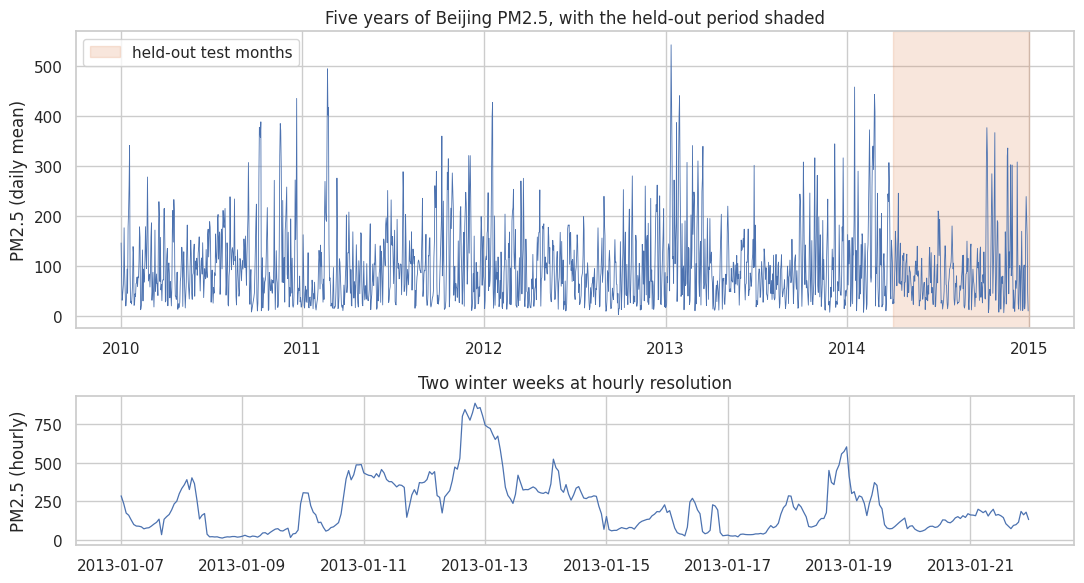

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), height_ratios=[2, 1])

# five years at daily resolution so the seasonal rhythm is visible
# daily means make five years readable; hourly detail comes below
daily = df["pm25"].resample("D").mean()
axes[0].plot(daily.index, daily.values, lw=0.6, color="#4C72B0")
axes[0].axvspan(df.index[val_end], df.index[-1], color="#DD8452", alpha=0.2,
                label="held-out test months")
axes[0].set_ylabel("PM2.5 (daily mean)")
axes[0].set_title("Five years of Beijing PM2.5, with the held-out period shaded")
axes[0].legend()

# two winter weeks at full hourly resolution to show what one hour ahead means
zoom = df["pm25"]["2013-01-07":"2013-01-21"]
axes[1].plot(zoom.index, zoom.values, lw=0.9, color="#4C72B0")
axes[1].set_ylabel("PM2.5 (hourly)")
axes[1].set_title("Two winter weeks at hourly resolution")

fig.tight_layout()
fig.savefig("fig/fig01_series.png", dpi=150, bbox_inches="tight")
plt.show()

The daily view shows the winter-heating rhythm and the severe episodes that make
forecasting matter. The hourly view shows the actual object of prediction: a jagged
series where the next hour is usually near the last one, which is exactly why persistence
is the baseline to respect.

### Figure 2: how the networks trained

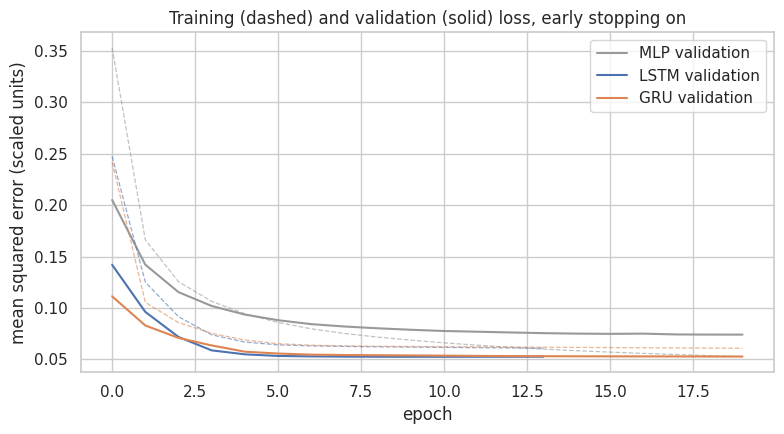

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for name, h, color in [("MLP", mlp_hist, "#999999"),
                       ("LSTM", lstm_hist, "#4C72B0"),
                       ("GRU", gru_hist, "#DD8452")]:
    ax.plot(h.history["val_loss"], label=f"{name} validation", color=color)
    ax.plot(h.history["loss"], ls="--", lw=0.9, color=color, alpha=0.6)
ax.set_xlabel("epoch")
ax.set_ylabel("mean squared error (scaled units)")
ax.set_title("Training (dashed) and validation (solid) loss, early stopping on")
ax.legend()
fig.tight_layout()
fig.savefig("fig/fig02_training.png", dpi=150, bbox_inches="tight")
plt.show()

All three networks converge within a handful of epochs and early stopping halts them
before the validation loss turns, so none of them is overfitted to the training years.

### Figure 3: the model comparison

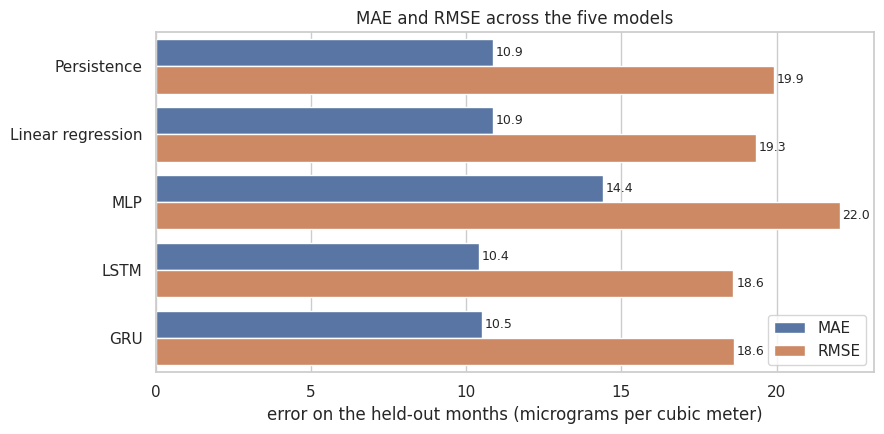

In [14]:
fig, ax = plt.subplots(figsize=(9, 4.5))
plot_df = results[["MAE", "RMSE"]].reset_index().melt(
    id_vars="model", var_name="metric", value_name="micrograms")
sns.barplot(data=plot_df, y="model", x="micrograms", hue="metric", ax=ax)
ax.set_xlabel("error on the held-out months (micrograms per cubic meter)")
ax.set_ylabel("")
ax.set_title("MAE and RMSE across the five models")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=2, fontsize=9)
ax.legend(title="")
fig.tight_layout()
fig.savefig("fig/fig03_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

### Figure 4: what the forecasts look like against reality

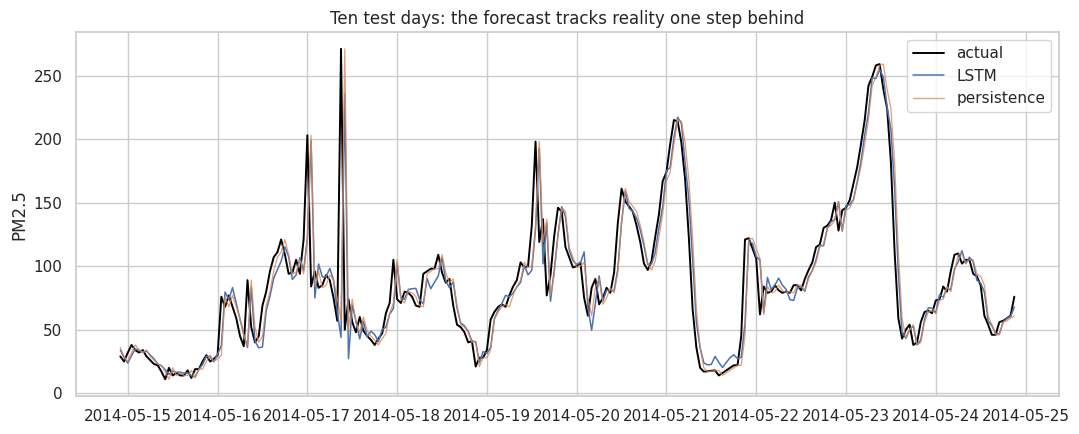

In [15]:
# one eventful test stretch, actual vs the recurrent model vs persistence
# an eventful stretch chosen from inside the held-out months
segment = slice(1000, 1240)   # a 10-day window, hours 1000 to 1240
t = df.index[val_end:][WINDOW:][segment]

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(t, y_test[segment], color="black", lw=1.4, label="actual")
ax.plot(t, preds["LSTM"][segment], color="#4C72B0", lw=1.1, label="LSTM")
ax.plot(t, preds["Persistence"][segment], color="#DD8452", lw=0.9,
        alpha=0.8, label="persistence")
ax.set_ylabel("PM2.5")
ax.set_title("Ten test days: the forecast tracks reality one step behind")
ax.legend()
fig.tight_layout()
fig.savefig("fig/fig04_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

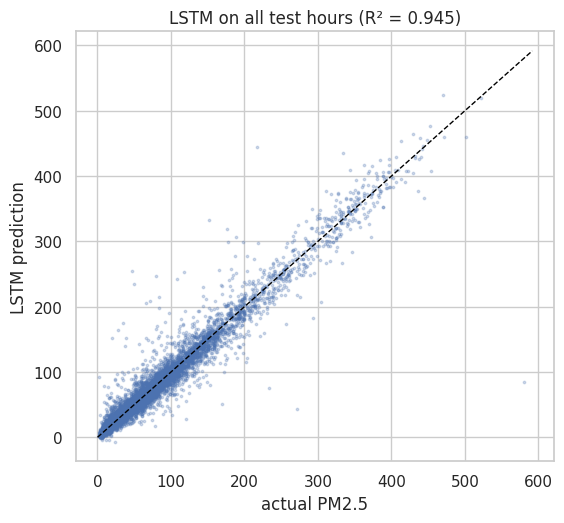

In [16]:
# predicted vs actual for the recurrent model across the whole test set
fig, ax = plt.subplots(figsize=(5.8, 5.4))
ax.scatter(y_test, preds["LSTM"], s=3, alpha=0.25, color="#4C72B0")
lims = [0, max(y_test.max(), preds["LSTM"].max()) * 1.02]
ax.plot(lims, lims, color="black", lw=1, ls="--")
ax.set_xlabel("actual PM2.5")
ax.set_ylabel("LSTM prediction")
r2 = r2_score(y_test, preds["LSTM"])
ax.set_title(f"LSTM on all test hours (R\u00b2 = {r2:.3f})")
fig.tight_layout()
fig.savefig("fig/fig05_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

### Figure 6: where the errors live

          hours  LSTM_MAE   Pers_MAE  LSTM_bias
band                                           
low        1975       6.0   5.600000        3.1
moderate   1689       9.3   9.900000        2.4
high       1897      11.7  12.500000       -0.4
severe     1009      18.5  19.700001       -2.3


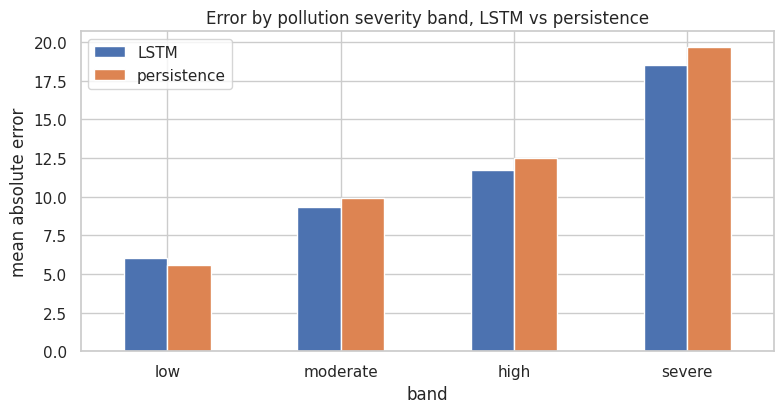

In [17]:
# error by severity band, the question a warning system actually cares about
# same band edges as the Prepare step
bands = pd.cut(y_test, [-1, 35, 75, 150, 10000],
               labels=["low", "moderate", "high", "severe"])
band_err = pd.DataFrame({
    "band": bands,
    "LSTM": np.abs(preds["LSTM"] - y_test),
    "Persistence": np.abs(preds["Persistence"] - y_test),
    "bias_LSTM": preds["LSTM"] - y_test,
})

summary = band_err.groupby("band", observed=True).agg(
    hours=("LSTM", "size"), LSTM_MAE=("LSTM", "mean"),
    Pers_MAE=("Persistence", "mean"), LSTM_bias=("bias_LSTM", "mean")).round(1)
print(summary.to_string())

fig, ax = plt.subplots(figsize=(8, 4.3))
summary[["LSTM_MAE", "Pers_MAE"]].plot(kind="bar", ax=ax, rot=0,
                                       color=["#4C72B0", "#DD8452"])
ax.set_ylabel("mean absolute error")
ax.set_title("Error by pollution severity band, LSTM vs persistence")
ax.legend(["LSTM", "persistence"])
fig.tight_layout()
fig.savefig("fig/fig06_severity.png", dpi=150, bbox_inches="tight")
plt.show()

Errors grow with the pollution level for every model, from about 6 micrograms in calm
hours to about 18.5 in the severe band for the LSTM. The recurrent model beats
persistence in every band above the low one, exactly where a warning system needs the
edge, and its bias in the severe band is a mild underestimate (about 2.3 micrograms on
average). Persistence is actually the better forecast in calm hours, which costs
nothing, since no one needs a warning at 20 micrograms.

### Findings summary

Written against the computed table above:

- The recurrent networks beat every other model on every metric: LSTM at MAE 10.4 and
  RMSE 18.6 against persistence at 10.9 and 19.9, with the GRU within a tenth of the
  LSTM. Reading the window as an ordered sequence is what wins.
- The memoryless models do not clearly beat persistence. Linear regression edges it on
  RMSE (19.3 vs 19.9) but loses on MAE, and the MLP loses outright (MAE 14.4). The same
  24 hours of history, handed over as a flat list, is barely worth more than the last
  reading alone.
- Put together, those two results sharpen the hypothesis: the history carries signal
  beyond the current reading, but the order of the hours is what unlocks it.
- Linear regression on the flattened window is still a respectable baseline (R-squared
  0.941), which is the Micro-Project 3 lesson landing where it belongs: the method that
  had to be forced onto a binary target is properly posed on a continuous one.
- Errors grow with pollution level for every model, and the LSTM's severe-band edge over
  persistence (18.5 vs 19.7 MAE) is modest, which bounds what the forecast should be
  trusted to do.
- The train_s column prices the comparison. The LSTM fits in well under a minute against
  under a second for the linear baseline, so the recurrent edge, while modest, is also
  cheap.

## Step 5 - Act

**Chosen model: the LSTM**, with the GRU as an equivalent substitute. It posts the lowest
error, reads the window as the ordered sequence it actually is, and fits in well under a
minute on this volume (the train_s column above), so the compute case against it is weak.

**Applied to the problem statement.** One hour ahead, the model tracks reality closely
enough to drive short-horizon exposure decisions: advisory refreshes, activity timing for
sensitive groups, and instrument sanity checks against sudden sensor faults. The
deployment shape is a rolling forecast recomputed hourly from the trailing 24-hour
window.

**Verdict on the hypothesis.** Part (b) is supported cleanly: the recurrent networks
beat the memoryless models on every metric. Part (a) is supported only through them: the
flat models given the same history barely match a persistence forecast, so it is not the
history alone that beats the last reading, it is the history read in order. The advantage
is real but modest at one hour ahead, because the next hour is genuinely dominated by the
current one.

**The honest boundary for action.** Errors concentrate in severe hours (MAE about 18.5
above 150 micrograms) and the model mildly underestimates there, so the forecast should
trigger conservative thresholds rather than replace monitoring. A warning rule built on
it should fire on the model's value minus a severity margin, and the severity-band table
is where that margin comes from.

**Limitations.** One city, one embassy monitor, 2010 to 2014, and a one-hour horizon.
Longer horizons need multi-step architectures, and a real system would retrain on rolling
data. Every result is an association learned from history and assumes the physical regime
that produced it, and interpolated stretches inside the longest gaps are reconstructions
rather than measurements.

**Closing the ePortfolio.** Four micro-projects, one discipline: audit before remedy
(MP1), describe before model (MP2), baseline before believing (MP3), and match the
technique to the target (MP3's feedback, applied here). The portfolio ends with the full
data science process run start to finish on two datasets, a cross-section and a time
series, with every verdict written from computed results.